# **02477 — The Missing Pieces**

Three things that are genuinely missing across all your notebooks:

1. **Decision flowchart** — how to recognise *which* tool to use in the first 30 seconds
2. **NumPy calculator** — your `tasks_scripts` uses JAX; all exam guides use NumPy. This bridges them
3. **ELBO / expected log-likelihood** — the full analytical derivation for the product model $y \sim \mathcal{N}(w_1 w_2, \sigma^2)$, which appeared on the 2024 exam and is missing from `derivations_02477`

---

## Part 1 — What Do I Do With This Question?

Read the question. Find the **first matching trigger** below. Open the file it points to.

---

### Trigger words → tool

| If the question says... | Task type | Open |
|---|---|---|
| *"determine the distribution p(...)"* | Type 1 | `task_type_guide` § 1 |
| *"determine the likelihood"* | Type 1 | `task_type_guide` § 1 |
| *"determine the prior"* | Type 1 | write it down directly |
| *"determine the posterior p(w|y)"* | Type 1 | `task_type_guide` § 1d |
| *"prior predictive p(y*|x*)"* | Type 2C | `task_type_guide` § 2C |
| *"posterior predictive p(y*|y, x*)"* | Type 2 | `task_type_guide` § 2 |
| *"plug-in approximation"* | Type 2D | `task_type_guide` § 2D |
| *"probit approximation"* | Type 2E | `task_type_guide` § 2E |
| *"compute the MLE"* | Type 3 | `tasks_scripts` § 2 |
| *"evaluate log p(y, w)"* | Type 4 | `task_type_guide` § 4A |
| *"log marginal likelihood"* | Type 4 | `task_type_guide` § 4B |
| *"marginal likelihood p(y)"* | Type 4 | `task_type_guide` § 4C |
| *"credibility interval"* | Type 5 | `task_type_guide` § 5 |
| *"probability of the event w > 0"* | Type 5 | `task_type_guide` § 5 |
| *"gradient and Hessian"* | Type 6 | `task_type_guide` § 6 |
| *"Laplace approximation"* | Type 6 | `task_type_guide` § 6 |
| *"entropy"* | Type 7 | `task_type_guide` § 7 |
| *"confidence"* | Type 7 | `task_type_guide` § 7 |
| *"estimate ... using the samples"* | Type 8 | `task_type_guide` § 8 |
| *"estimate the posterior probability"* | Type 8 | `task_type_guide` § 8 |
| *"95% interval ... using samples"* | Type 8 | `task_type_guide` § 8 |
| *"run a Metropolis chain"* | Type 9 | `task_type_guide` § 9 |
| *"grid approximation"* | Type 10 | `task_type_guide` § 10 |
| *"explain how you expect ... to change"* | Type 11 | `task_type_guide` § 11 |
| *"verify that w_MAP is correct"* | Type 12 | `task_type_guide` § 12 |
| *"identify the prior and likelihood"* | Type 13 | `task_type_guide` § 13 |
| *"magnitude and lengthscale"* | Type 13 | `task_type_guide` § 13A |
| *"stationary" / "isotropic"* | Type 13 | `task_type_guide` § 13B |
| *"expected utility" / "optimal decision"* | Type 14 | `task_type_guide` § 14 |
| *"ancestral sampling"* | Type 15 | `task_type_guide` § 15 |

---

### The 5 results you can always write immediately — no calculation needed

| Situation | Answer |
|---|---|
| Prior $p(w > 0)$ for zero-mean Gaussian prior | **= 0.5** (prior is symmetric) |
| Laplace $p(w > w_{\text{MAP}})$ | **= 0.5** (Laplace is Gaussian centred at MAP) |
| GP prior predictive $p(y^*=0 \| x^*)$ for zero-mean GP | **= 0.5** (GP prior is symmetric) |
| Mean-field posterior $\text{Cov}(w_i, w_j)$ for $i\neq j$ | **= 0** (mean-field = independence) |
| Gradient $\nabla_w \log p(y,w)$ at MAP | **= 0** (definition of a maximum) |

---

### When you have NO IDEA what the question wants

1. Look at the **output**: is it a distribution (Gaussian, Bernoulli)? → Type 1 or 2
2. Is it a **single number** (probability, interval, mean)? → Type 5, 7, or 8
3. Is it a **plot** (traces, contours)? → Type 9
4. Is it a **written explanation**? → Type 11, 12, or 13

---

## Part 2 — NumPy Calculator (JAX-free)

Your `tasks_scripts` uses JAX. All exam solution guides and the codebook use NumPy/SciPy. These blocks give you the same functionality in pure NumPy — no JAX, no import errors, no type mismatches.

**How to use:** Find the matching section → update the `INPUTS` block → run → copy number.

---

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal as mvn, poisson, beta as beta_dist
from scipy.optimize import minimize

np.random.seed(42)

# Helpers
sigmoid  = lambda a: 1.0 / (1.0 + np.exp(-a))
softmax  = lambda f: np.exp(f - np.max(f)) / np.sum(np.exp(f - np.max(f)))
log_npdf = lambda x, m, v: -0.5*np.log(2*np.pi*v) - 0.5*(x-m)**2/v
npdf     = lambda x, m, v: np.exp(log_npdf(x, m, v))
log_ber  = lambda y, p: y*np.log(np.clip(p,1e-12,1)) + (1-y)*np.log(np.clip(1-p,1e-12,1))
print('NumPy helpers loaded — no JAX needed.')

NumPy helpers loaded — no JAX needed.


### N1 — MAP via numerical optimisation

In [2]:
# ── INPUTS ──────────────────────────────────────────────────────────────────
X_data = np.array([[0., 0.], [1., 1.]])
y_data = np.array([0., 1.])
lam    = 1/4          # prior precision
w_init = np.zeros(2)

# ── YOUR LOG JOINT — change this for your model ──────────────────────────────
def log_joint_fn(w):
    # Bernoulli / logistic regression
    p         = sigmoid(X_data @ w)
    log_lik   = np.sum(log_ber(y_data, p))
    log_prior = np.sum(log_npdf(w, 0, 1/lam))
    return log_lik + log_prior
    # Gaussian linear regression:
    # Phi = np.column_stack([np.ones(len(X_data)), X_data])
    # log_lik = -0.5/sigma2 * np.sum((y_data - Phi@w)**2)
    # return log_lik + np.sum(log_npdf(w, 0, 1/lam))
    # Poisson GLM:
    # mu = np.exp(3 + X_data @ w)
    # return poisson.logpmf(y_data.astype(int), mu).sum() + mvn.logpdf(w, np.zeros(len(w)), (1/lam)*np.eye(len(w)))

# ── CALCULATION ──────────────────────────────────────────────────────────────
eps = 1e-5
result = minimize(
    lambda w: -log_joint_fn(w),
    w_init,
    jac=lambda w: np.array([
        -(log_joint_fn(w + eps*np.eye(len(w))[i]) - log_joint_fn(w - eps*np.eye(len(w))[i])) / (2*eps)
        for i in range(len(w))
    ]),
    method='BFGS'
)
w_MAP = result.x
print(f'w_MAP           = {np.round(w_MAP, 6)}')
print(f'log p(y, w_MAP) = {log_joint_fn(w_MAP):.4f}')

w_MAP           = [0.740774 0.740774]
log p(y, w_MAP) = -4.2593


### N2 — Laplace approximation (Hessian → covariance → probit predictive)

In [3]:
# Runs after N1. Uses w_MAP and log_joint_fn from above.

# ── INPUTS ──────────────────────────────────────────────────────────────────
x_star_N2 = np.array([0., 1.])   # test point

# ── Analytical Hessian for logistic regression ──────────────────────────────
p_n    = sigmoid(X_data @ w_MAP)
S_nn   = p_n * (1 - p_n)                                    # S_nn = sigma*(1-sigma)
H_N2   = -X_data.T @ np.diag(S_nn) @ X_data - lam*np.eye(X_data.shape[1])
S_N2   = -np.linalg.inv(H_N2)
print(f'Hessian H  =\n{np.round(H_N2,4)}')
print(f'Laplace S  =\n{np.round(S_N2,4)}')
print()

# Posterior of f* and probit
mu_f_N2  = w_MAP @ x_star_N2
var_f_N2 = x_star_N2 @ S_N2 @ x_star_N2
p_probit = norm.cdf(mu_f_N2 / np.sqrt(8/np.pi + var_f_N2))
print(f'Plug-in:  p(y*=1|y,x*) = sigma({mu_f_N2:.4f}) = {sigmoid(mu_f_N2):.4f}')
print(f'Posterior f*: N({mu_f_N2:.4f}, {var_f_N2:.4f})')
print(f'Probit:   p(y*=1|y,x*) = {p_probit:.4f}')

Hessian H  =
[[-0.4009 -0.1509]
 [-0.1509 -0.4009]]
Laplace S  =
[[ 2.9061 -1.0939]
 [-1.0939  2.9061]]

Plug-in:  p(y*=1|y,x*) = sigma(0.7408) = 0.6772
Posterior f*: N(0.7408, 2.9061)
Probit:   p(y*=1|y,x*) = 0.6245


### N3 — Metropolis sampler

Acceptance rate: 0.09
Posterior samples: 9001


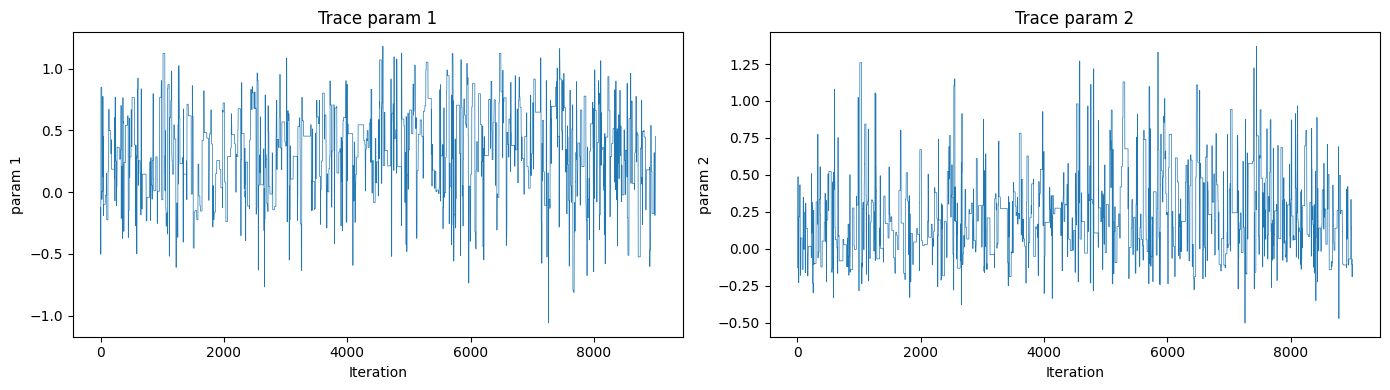

In [4]:
# ── INPUTS ──────────────────────────────────────────────────────────────────
init_z       = [0.0, 1.5]
n_iter       = 10_000
proposal_std = 1.0       # tau — proposal covariance = tau^2 * I
warmup_frac  = 0.1
seed         = 42

# ── YOUR LOG TARGET — change this ────────────────────────────────────────────
def log_target(theta):
    z1, z2 = theta[0], theta[1]
    return -(1-z1)**2 - 20*(z2-z1**2)**2 - z1**2 - z2**2
    # Non-linear model y=w2*tanh(w1*x)+eps, w~N(0,I):
    # w1,w2 = theta
    # return log_npdf(y_obs, w2*np.tanh(w1*x_obs), sigma2) + log_npdf(w1,0,1) + log_npdf(w2,0,1)
    # Two-variable x|z~N(0,e^z), z~N(1,1):
    # z,x = theta
    # return log_npdf(z,1,1) + log_npdf(x,0,np.exp(z))
    # Poisson GLM:
    # w1,w2=theta; alpha=8; x_d=np.array([1.,2.,3.]); y_d=np.array([10,4,1])
    # X_d=np.column_stack([x_d,x_d**2]); mu_d=np.exp(3+X_d@np.array([w1,w2]))
    # return poisson.logpmf(y_d,mu_d).sum()+mvn.logpdf(np.array([w1,w2]),np.zeros(2),(1/alpha)*np.eye(2))

# ── SAMPLER ──────────────────────────────────────────────────────────────────
np.random.seed(seed)
D=len(init_z); curr=np.array(init_z,dtype=float)
samps=[curr.copy()]; log_p=log_target(curr); n_acc=0
for _ in range(n_iter):
    prop=samps[-1]+proposal_std*np.random.randn(D); lp=log_target(prop)
    if np.log(np.random.uniform()) < lp-log_p:
        samps.append(prop); log_p=lp; n_acc+=1
    else:
        samps.append(samps[-1].copy())
all_samples=np.array(samps)
warmup=int(warmup_frac*n_iter)
posterior=all_samples[warmup:]
print(f'Acceptance rate: {n_acc/n_iter:.2f}')
print(f'Posterior samples: {len(posterior)}')
fig,axes=plt.subplots(1,D,figsize=(7*D,4))
if D==1: axes=[axes]
for i,ax in enumerate(axes):
    ax.plot(posterior[:,i],lw=0.5)
    ax.set(xlabel='Iteration',ylabel=f'param {i+1}',title=f'Trace param {i+1}')
plt.tight_layout(); plt.show()

### N4 — MC estimators from posterior samples

In [5]:
# Uses 'posterior' from N3. Or define your own:
# posterior = np.random.multivariate_normal([1,0], [[1,0.5],[0.5,5]], 6000)

p1, p2 = posterior[:,0], posterior[:,1]

print('== Expectations ==')
print(f'E[param1]          = {np.mean(p1):.4f}')
print(f'E[param2]          = {np.mean(p2):.4f}')
print(f'E[(p1-p2)^2]       = {np.mean((p1-p2)**2):.4f}')
print(f'E[sin(p1*p2)]      = {np.mean(np.sin(p1*p2)):.4f}')
print()
print('== Probabilities ==')
print(f'p(param1 > 0)      = {np.mean(p1>0):.4f}')
print(f'p(param1 > param2) = {np.mean(p1>p2):.4f}')
print(f'p(param2 < 1)      = {np.mean(p2<1):.4f}')
print()
for pct in [80,90,95]:
    t=(100-pct)/2
    print(f'  {pct}% CI param1: [{np.percentile(p1,t):.4f}, {np.percentile(p1,100-t):.4f}]')
print()
# Ancestral sampling
x_star_N4=2.0; sigma2_N4=2.0
f_N4=lambda x,w1,w2: w2*np.tanh(w1*x)
np.random.seed(123)
fstar=f_N4(x_star_N4,p1,p2)
ystar=fstar+np.sqrt(sigma2_N4)*np.random.randn(len(p1))
print(f'== Posterior predictive at x*={x_star_N4} ==')
print(f'E[f*]      = {np.mean(fstar):.4f}')
print(f'E[y*]      = {np.mean(ystar):.4f}')
print(f'p(f* > 1)  = {np.mean(fstar>1):.4f}')
print(f'95% CI y*: [{np.percentile(ystar,2.5):.4f}, {np.percentile(ystar,97.5):.4f}]')

== Expectations ==
E[param1]          = 0.3357
E[param2]          = 0.2257
E[(p1-p2)^2]       = 0.0943
E[sin(p1*p2)]      = 0.1351

== Probabilities ==
p(param1 > 0)      = 0.8144
p(param1 > param2) = 0.7371
p(param2 < 1)      = 0.9792

  80% CI param1: [-0.1491, 0.7970]
  90% CI param1: [-0.2576, 0.9065]
  95% CI param1: [-0.4595, 1.0053]

== Posterior predictive at x*=2.0 ==
E[f*]      = 0.1721
E[y*]      = 0.1900
p(f* > 1)  = 0.0196
95% CI y*: [-2.6342, 3.0280]


### N5 — Entropy, KL, credibility intervals (VI)

In [6]:
# ── INPUTS ──────────────────────────────────────────────────────────────────
mu_vi = np.array([-0.82,  2.37, -0.88,  0.37])   # variational means
v_vi  = np.array([ 0.38,  0.19,  0.13,  0.09])   # variational variances
k_ci  = 1    # which parameter to compute CI for (0-indexed)

# Mean-field entropy
H_vi = 0.5*np.sum(np.log(2*np.pi*np.e*v_vi))
print(f'H[q] = {H_vi:.4f}')
print()

# KL[N(m,v) || N(0,1)] — standard prior
kl_each = 0.5*(v_vi + mu_vi**2 - 1 - np.log(v_vi))
print(f'KL[q||N(0,1)] = {np.sum(kl_each):.4f}  (per dim: {np.round(kl_each,4)})')
print()

# Credibility intervals
std_ci = np.sqrt(v_vi[k_ci])
for pct,z in [(80,1.282),(90,1.645),(95,1.960),(99,2.576)]:
    lo,hi = mu_vi[k_ci]-z*std_ci, mu_vi[k_ci]+z*std_ci
    print(f'  {pct}% CI param {k_ci}: [{lo:.4f}, {hi:.4f}]  (z={z})')
print()

# Tail probability
c=0.0
p_above = 1-norm.cdf(c, loc=mu_vi[k_ci], scale=std_ci)
print(f'p(param{k_ci} > {c}) = {p_above:.4f}')
print('Prior p(w > 0)     = 0.5  (zero-mean Gaussian is symmetric)')
print('Laplace p(w>w_MAP) = 0.5  (Laplace is Gaussian centred at MAP)')

H[q] = 2.1375

KL[q||N(0,1)] = 5.5335  (per dim: [0.51   3.2338 0.9723 0.8174])

  80% CI param 1: [1.8112, 2.9288]  (z=1.282)
  90% CI param 1: [1.6530, 3.0870]  (z=1.645)
  95% CI param 1: [1.5157, 3.2243]  (z=1.96)
  99% CI param 1: [1.2471, 3.4929]  (z=2.576)

p(param1 > 0.0) = 1.0000
Prior p(w > 0)     = 0.5  (zero-mean Gaussian is symmetric)
Laplace p(w>w_MAP) = 0.5  (Laplace is Gaussian centred at MAP)


### N6 — Beta-Binomial model

Prior:     Beta(1.0, 1.0)
Data:      N=10, y=3  (MLE = 0.3000)
Posterior: Beta(4.0, 8.0)
  Mean:    0.3333  (Bayes estimator)
  Std:     0.1307
  95% CI:  [0.1093, 0.6097]
Posterior predictive p(y*=1) = E[theta|data] = 0.3333


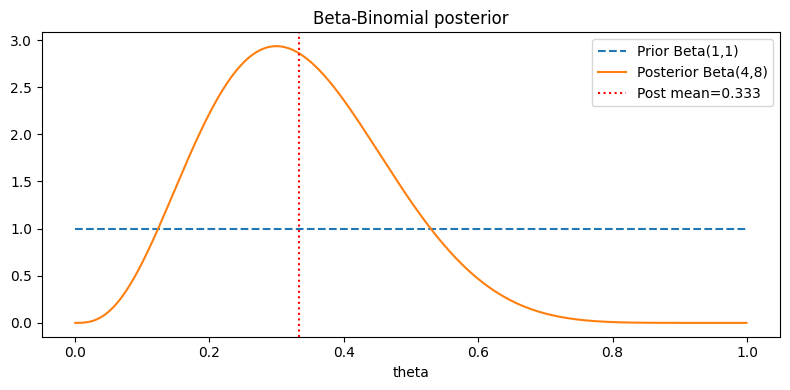

In [7]:
# ── INPUTS ──────────────────────────────────────────────────────────────────
a0, b0 = 1.0, 1.0    # prior Beta(a0,b0)  [uniform prior = 1,1]
N_obs  = 10          # total trials
y_obs  = 3           # successes

# ── CALCULATION ──────────────────────────────────────────────────────────────
a_post = a0 + y_obs
b_post = b0 + (N_obs - y_obs)
post_mean = a_post / (a_post + b_post)
post_var  = (a_post*b_post) / ((a_post+b_post)**2 * (a_post+b_post+1))
CI_lo, CI_hi = beta_dist.ppf([0.025, 0.975], a_post, b_post)
MLE = y_obs / N_obs

print(f'Prior:     Beta({a0}, {b0})')
print(f'Data:      N={N_obs}, y={y_obs}  (MLE = {MLE:.4f})')
print(f'Posterior: Beta({a_post}, {b_post})')
print(f'  Mean:    {post_mean:.4f}  (Bayes estimator)')
print(f'  Std:     {np.sqrt(post_var):.4f}')
print(f'  95% CI:  [{CI_lo:.4f}, {CI_hi:.4f}]')
print(f'Posterior predictive p(y*=1) = E[theta|data] = {post_mean:.4f}')

# Plot prior vs posterior
theta_grid = np.linspace(0.001, 0.999, 500)
fig,ax = plt.subplots(figsize=(8,4))
ax.plot(theta_grid, beta_dist.pdf(theta_grid,a0,b0), '--', label=f'Prior Beta({int(a0)},{int(b0)})')
ax.plot(theta_grid, beta_dist.pdf(theta_grid,a_post,b_post), label=f'Posterior Beta({int(a_post)},{int(b_post)})')
ax.axvline(post_mean, color='r', lw=1.5, linestyle=':', label=f'Post mean={post_mean:.3f}')
ax.set(xlabel='theta', title='Beta-Binomial posterior')
ax.legend(); plt.tight_layout(); plt.show()

### N7 — R-hat and ESS convergence diagnostics

In [8]:
# Run two chains from N3 with different seeds, then paste here.
# Or use these toy examples to test the functions.

# ── Build two example chains ──────────────────────────────────────────────────
def run_chain_N7(init, seed, n=3000, tau=1.0):
    np.random.seed(seed)
    curr=np.array(init); samps=[curr.copy()]; log_p=log_target(curr)
    for _ in range(n):
        prop=samps[-1]+tau*np.random.randn(len(curr)); lp=log_target(prop)
        if np.log(np.random.uniform()) < lp-log_p:
            samps.append(prop); log_p=lp
        else:
            samps.append(samps[-1].copy())
    return np.array(samps)[300:]   # 10% warmup

chain1_N7 = run_chain_N7([0.0, 1.5],  seed=1)
chain2_N7 = run_chain_N7([1.0,-1.0], seed=2)
chains = np.stack([chain1_N7, chain2_N7])   # shape (2, n_samples, n_params)

# ── R-hat ────────────────────────────────────────────────────────────────────
def rhat(chains):
    M, S, D = chains.shape
    chain_means = chains.mean(axis=1)
    grand_mean  = chains.mean(axis=(0,1))
    B = S/(M-1) * np.sum((chain_means - grand_mean)**2, axis=0)
    W = np.mean(np.var(chains, axis=1, ddof=1), axis=0)
    var_plus = ((S-1)/S)*W + B/S
    return np.sqrt(var_plus/W)

# ── ESS ──────────────────────────────────────────────────────────────────────
def ess(chains):
    M, S, D = chains.shape
    all_s = chains.reshape(-1, D)
    ess_v = []
    for d in range(D):
        x = all_s[:,d]; x=(x-x.mean())/(x.std()+1e-8)
        acf = np.correlate(x,x,mode='full')[len(x)-1:]; acf=acf/acf[0]
        rho_sum=0
        for t in range(1,len(acf)//2):
            pair=acf[2*t-1]+acf[2*t]
            if pair<0: break
            rho_sum+=pair
        ess_v.append(len(all_s)/(1+2*rho_sum))
    return np.array(ess_v)

rhat_v = rhat(chains)
ess_v  = ess(chains)
for d in range(chains.shape[2]):
    status = 'CONVERGED' if rhat_v[d] < 1.1 else 'NOT CONVERGED'
    print(f'Param {d+1}: R-hat={rhat_v[d]:.4f} ({status}),  ESS={ess_v[d]:.0f}/{len(chains.reshape(-1,2))} total')
print()
print('R-hat < 1.1 = chains have mixed (safe to use)')
print('ESS > 100   = sufficient for reliable estimates')

Param 1: R-hat=1.0092 (CONVERGED),  ESS=238/5402 total
Param 2: R-hat=1.0046 (CONVERGED),  ESS=200/5402 total

R-hat < 1.1 = chains have mixed (safe to use)
ESS > 100   = sufficient for reliable estimates


---
## Part 3 — ELBO: Expected Log-Likelihood Full Derivation

This appeared on **May 2024 Q4.2** and is **not in `derivations_02477`** as a worked example.

### The model

$$y|w_1,w_2 \sim \mathcal{N}(w_1 w_2, \sigma^2), \quad w_1,w_2 \sim \mathcal{N}(0,1)$$
$$q(w_1,w_2) = \mathcal{N}(w_1|m_1,v_1)\,\mathcal{N}(w_2|m_2,v_2) \quad \text{(mean-field)}$$

---

### The two moment facts you must memorise

For $w \sim \mathcal{N}(m, v)$:

$$\boxed{\mathbb{E}[w] = m \qquad \mathbb{E}[w^2] = m^2 + v}$$

The second follows from $\text{Var}(w) = \mathbb{E}[w^2] - m^2 = v$.

Under mean-field (independent $w_1, w_2$):

$$\boxed{\mathbb{E}[w_1 w_2] = m_1 m_2} \qquad \boxed{\mathbb{E}[w_1^2 w_2^2] = (m_1^2+v_1)(m_2^2+v_2)}$$

---

### 6-step derivation (write this on paper)

**Step 1** — Write the log-likelihood:
$$\log p(y|w_1,w_2) = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}(y - w_1 w_2)^2$$

**Step 2** — Take $\mathbb{E}_q$. The constant stays, expand the square:
$$\mathbb{E}_q[\log p] = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\,\mathbb{E}_q[(y-w_1w_2)^2]$$

**Step 3** — Expand $(y-w_1w_2)^2 = y^2 - 2y w_1w_2 + w_1^2w_2^2$:
$$\mathbb{E}_q[(y-w_1w_2)^2] = y^2 - 2y\,\mathbb{E}[w_1w_2] + \mathbb{E}[w_1^2w_2^2]$$

**Step 4** — Apply moment facts:
$$= y^2 - 2y m_1 m_2 + (m_1^2+v_1)(m_2^2+v_2)$$

**Step 5** — Expand $(m_1^2+v_1)(m_2^2+v_2)$ and recognise a perfect square:
$$= \underbrace{y^2 - 2ym_1m_2 + m_1^2m_2^2}_{(y-m_1m_2)^2} + m_1^2v_2 + v_1m_2^2 + v_1v_2$$

**Step 6** — Final answer:
$$\boxed{\mathbb{E}_q[\log p(y|w_1,w_2)] = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\Big[(y-m_1m_2)^2 + m_1^2v_2 + v_1m_2^2 + v_1v_2\Big]}$$

---

### What the 4 terms mean

| Term | Meaning |
|------|--------|
| $(y-m_1m_2)^2$ | Squared bias — how far the mean prediction is from $y$ |
| $m_1^2 v_2$ | Uncertainty in $w_2$, amplified by $m_1$ |
| $v_1 m_2^2$ | Uncertainty in $w_1$, amplified by $m_2$ |
| $v_1 v_2$ | Joint uncertainty — always hurts, even if both biases are zero |

---

### Full ELBO = expected log-likelihood − KL to prior

For $w_i \sim \mathcal{N}(0,1)$ priors:
$$\text{KL}[\mathcal{N}(m_i,v_i)\|\mathcal{N}(0,1)] = \frac{1}{2}(v_i + m_i^2 - 1 - \ln v_i)$$
$$\mathcal{L}[q] = \mathbb{E}_q[\log p(y|w_1,w_2)] - \text{KL}_1 - \text{KL}_2$$

---

### Generalisation — any linear model $y \sim \mathcal{N}(w^T\phi, \sigma^2)$

$$\mathbb{E}_q[(y-w^T\phi)^2] = (y - m^T\phi)^2 + \phi^T\,\text{diag}(v)\,\phi$$

This is simpler than the product case because $w^T\phi$ is linear in each $w_i$ separately.

---

In [9]:
# ── Verify the derivation numerically ────────────────────────────────────────
y_val=1.0; sigma2=1.0; m1,m2=-1.0,1.0; v1,v2=1.0,1.0

bias_sq   = (y_val-m1*m2)**2
var_terms = m1**2*v2 + v1*m2**2 + v1*v2
E_sq      = bias_sq + var_terms
E_loglik  = -0.5*np.log(2*np.pi*sigma2) - 0.5/sigma2*E_sq

print('Analytical expected log-likelihood:')
print(f'  (y-m1*m2)^2 = ({y_val}-{m1}*{m2})^2 = {bias_sq:.4f}')
print(f'  m1^2*v2     = {m1**2*v2:.4f}')
print(f'  v1*m2^2     = {v1*m2**2:.4f}')
print(f'  v1*v2       = {v1*v2:.4f}')
print(f'  E[(y-f)^2]  = {E_sq:.4f}')
print(f'  E_q[log p]  = {E_loglik:.4f}')
print()
np.random.seed(42); S=1_000_000
w1s=np.random.normal(m1,np.sqrt(v1),S); w2s=np.random.normal(m2,np.sqrt(v2),S)
mc=-0.5*np.log(2*np.pi*sigma2) - 0.5*(y_val-w1s*w2s)**2/sigma2
print(f'Monte Carlo check: {np.mean(mc):.4f}  (should equal {E_loglik:.4f})')
print()
kl1=0.5*(v1+m1**2-1-np.log(v1)); kl2=0.5*(v2+m2**2-1-np.log(v2))
elbo=E_loglik-kl1-kl2
print(f'KL[q1||N(0,1)] = {kl1:.4f}')
print(f'KL[q2||N(0,1)] = {kl2:.4f}')
print(f'ELBO = {elbo:.4f}')

Analytical expected log-likelihood:
  (y-m1*m2)^2 = (1.0--1.0*1.0)^2 = 4.0000
  m1^2*v2     = 1.0000
  v1*m2^2     = 1.0000
  v1*v2       = 1.0000
  E[(y-f)^2]  = 7.0000
  E_q[log p]  = -4.4189

Monte Carlo check: -4.4251  (should equal -4.4189)

KL[q1||N(0,1)] = 0.5000
KL[q2||N(0,1)] = 0.5000
ELBO = -5.4189


---
## Summary

| Gap | What this file gives you |
|-----|-------------------------|
| **No decision procedure** | Part 1: trigger-word table, 5 free answers, no-idea triage |
| **JAX vs NumPy mismatch** | Part 2: N1–N7 replicate every `tasks_scripts` block in pure NumPy/SciPy |
| **ELBO derivation missing** | Part 3: 6-step pen-and-paper proof, moment facts, MC verification, generalisation |

**Recommended exam workflow:**
1. Read question → Part 1 trigger table → identify task type
2. Open `task_type_guide` for that type → run the code block
3. If you need to write math on paper → `derivations_02477` + Part 3 of this file